# Task 3 - ICP

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import pandas as pd
from typing import List, Tuple
from scipy.spatial.transform import Rotation
import time
from tqdm.notebook import tqdm

from tools.pcd_tools import downsample_voxel, pcd_from_path
from tools.plot_tools import plot_pcd, show_pcl, view_frames, plot_map_and_trajectories
from tools.analysis_tools import calc_error, calculate_lateral_errors
from tools.ICP import ICP, rigid_transformation, calculate_centroid
from tools.dataset import FrameDataset

In [3]:
# Paths to dataset
DATASET_DIR = "./dataset"  # Update this to your dataset path
MAP_PATH = os.path.join(DATASET_DIR, "map.pcd")
GT_PATH = os.path.join(DATASET_DIR, "ground_truth.csv")
FRAMES_DIR = os.path.join(DATASET_DIR, "frames")

## Dataset

In [4]:
dataset = FrameDataset(FRAMES_DIR, GT_PATH)

map_pcd = pcd_from_path(MAP_PATH)

print(f"Number of frames: {len(dataset)}")

# Get the first frame
pcd, gt_pos, gt_orientation = dataset[0]

Number of frames: 1014


In [5]:
view_frames([dataset[i][0] for i in range(len(dataset))])

## ICP Run

In [6]:
# Define parameters
voxel_size = 0.25  # Voxel size for downsampling
max_frames = 1500   # Optional: limit number of frames to process
num_frames = min(len(dataset), max_frames)

# Lists to track results
gt_positions = []
estimated_positions = []
position_errors = []
computation_times = []

# Initialize transformation matrix (identity matrix)
# This will keep track of our current position and orientation
current_transformation = np.eye(4)

# Get the initial pose from ground truth to initialize
init_pcd, init_pos, init_orientation = dataset[0]
init_rot = Rotation.from_euler('xyz', init_orientation, degrees=False).as_matrix()

# Initialize with first ground truth position
init_transform = np.eye(4)
init_transform[:3, :3] = init_rot
init_transform[:3, 3] = init_pos
current_transformation = init_transform

# Process frames
pbar = tqdm(range(1, num_frames), desc="Processing frames", leave=True)

# Create ICP object
icp = ICP(max_iterations=100, max_dist=5.0, tol=1e-6)

map_pcd_voxel, _ = downsample_voxel(map_pcd, voxel_size)

for i in pbar:
    # Get the current frame
    pcd, gt_pos, gt_orientation = dataset[i]
    
    # Store ground truth position
    gt_positions.append(gt_pos)
    
    # Voxelize the point clouds to reduce complexity
    start_time = time.time()
    pcd_voxel, _ = downsample_voxel(pcd, voxel_size)
    
    
    # Create homogeneous coordinates (Nx4)
    homogeneous_points = np.hstack((pcd_voxel, np.ones((pcd_voxel.shape[0], 1))))
    # Apply transformation
    transformed_points = np.dot(homogeneous_points, current_transformation.T)
    # Convert back to 3D points
    pcd_voxel = transformed_points[:, :3]
    
    
    
    # Run ICP to align current scan with map
    R, t, _, _, _ = icp.align(pcd_voxel, map_pcd_voxel)
    
    # Create transformation matrix from ICP result
    icp_transform = np.eye(4)
    icp_transform[:3, :3] = R
    # Fix the shape issue - reshape t to be 1D if it's a column vector
    if t.ndim > 1:  # If t is 2D (like shape (3,1))
        t = t.flatten()  # Convert to 1D array
    icp_transform[:3, 3] = t
    
    # Update the current transformation with the ICP result
    current_transformation = np.matmul(icp_transform, current_transformation)
    
    # Extract current position from transformation matrix
    current_position = current_transformation[:3, 3]
    
    # Store estimated position
    estimated_positions.append(current_position)
    
    # Compute error
    position_error = np.linalg.norm(current_position - gt_pos)
    position_errors.append(position_error)
    
    # Compute execution time
    execution_time = time.time() - start_time
    computation_times.append(execution_time)
    
    # Update progress bar with current error
    pbar.set_postfix({"Position Error": f"{position_error:.2f}m", "Time": f"{execution_time:.2f}s"})

# Convert lists to numpy arrays
gt_positions = np.array(gt_positions)
estimated_positions = np.array(estimated_positions)
position_errors = np.array(position_errors)
computation_times = np.array(computation_times)

Processing frames:   0%|          | 0/1013 [00:00<?, ?it/s]

: 

## Analysis

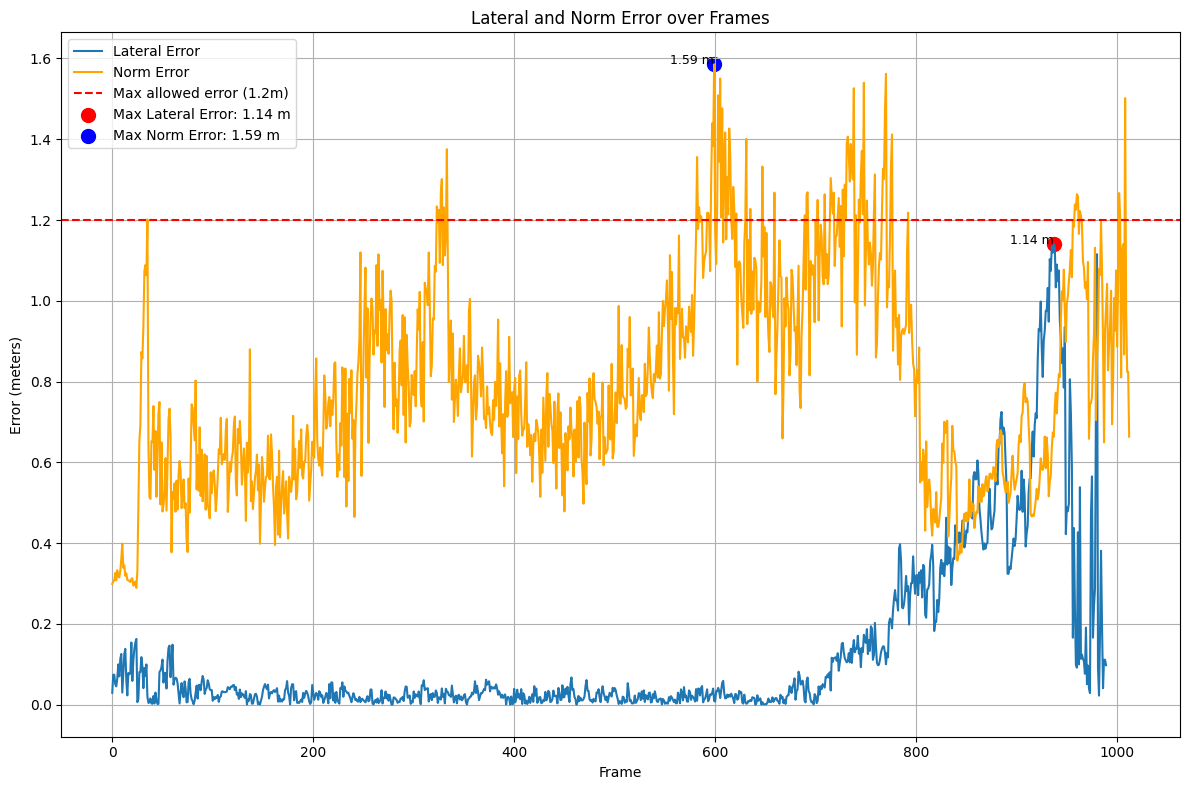

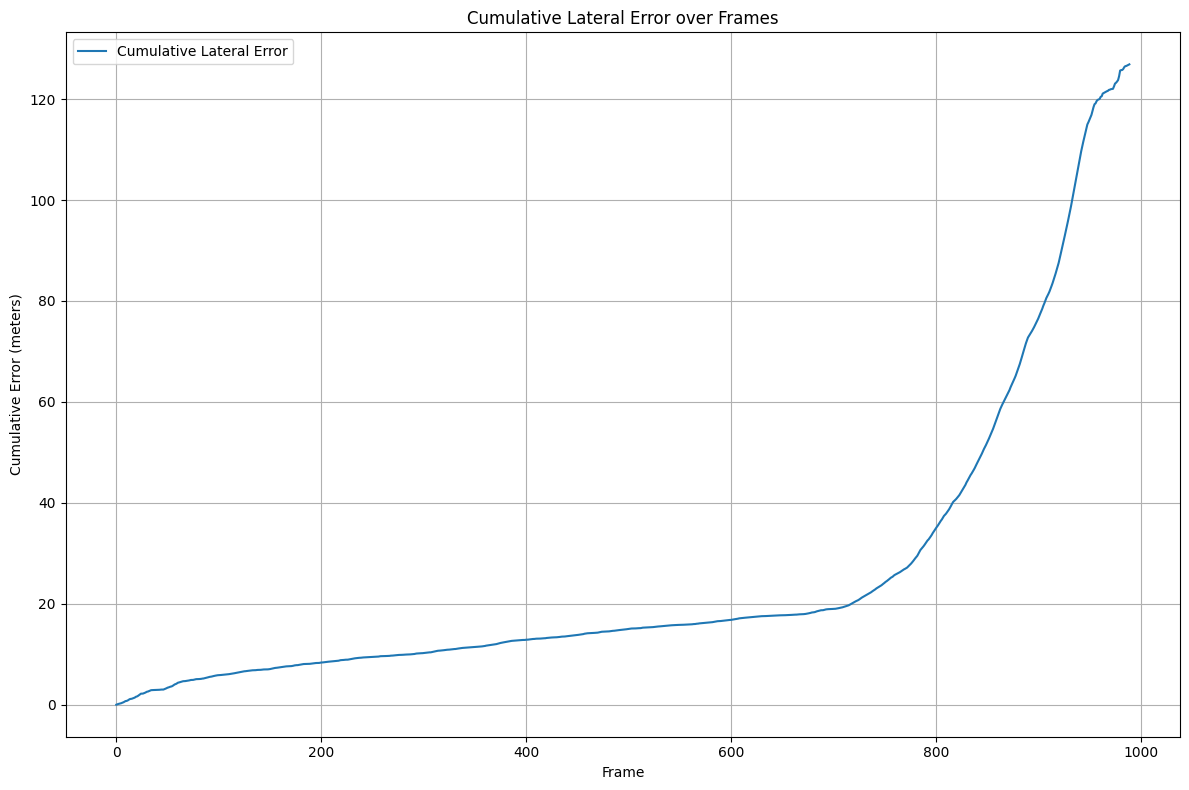

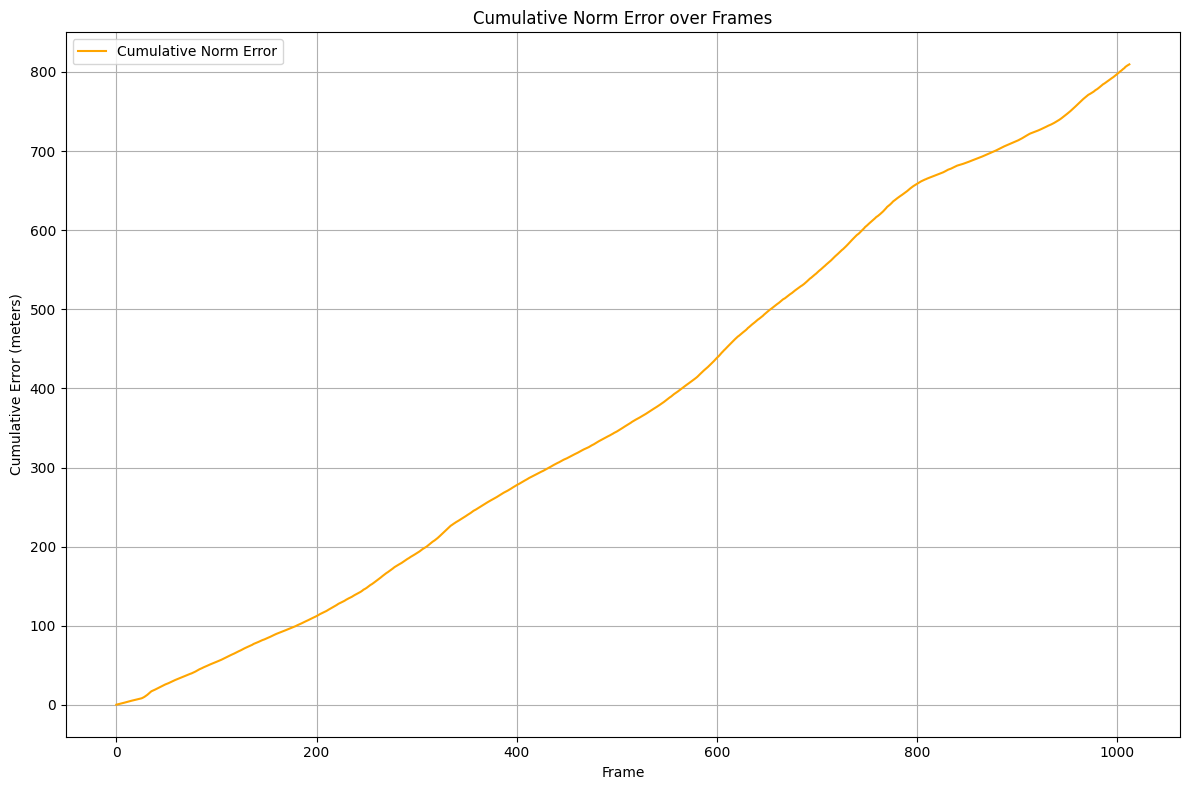

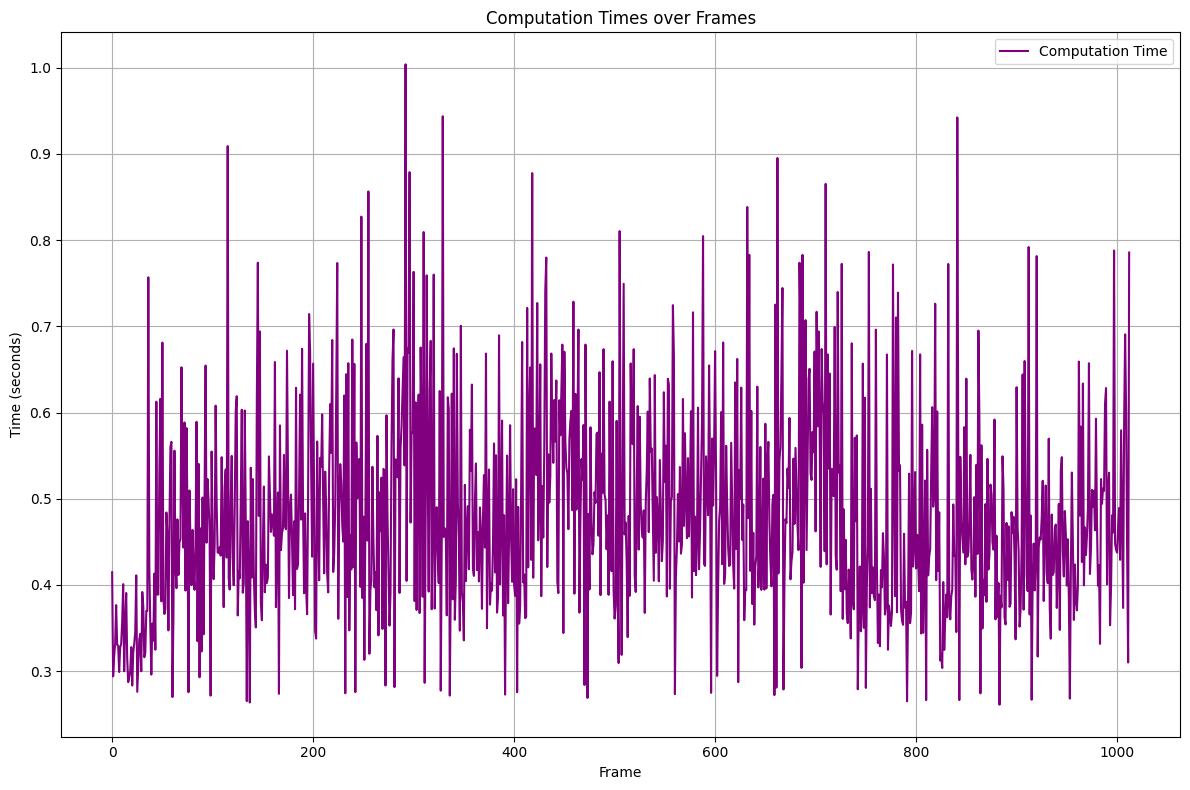

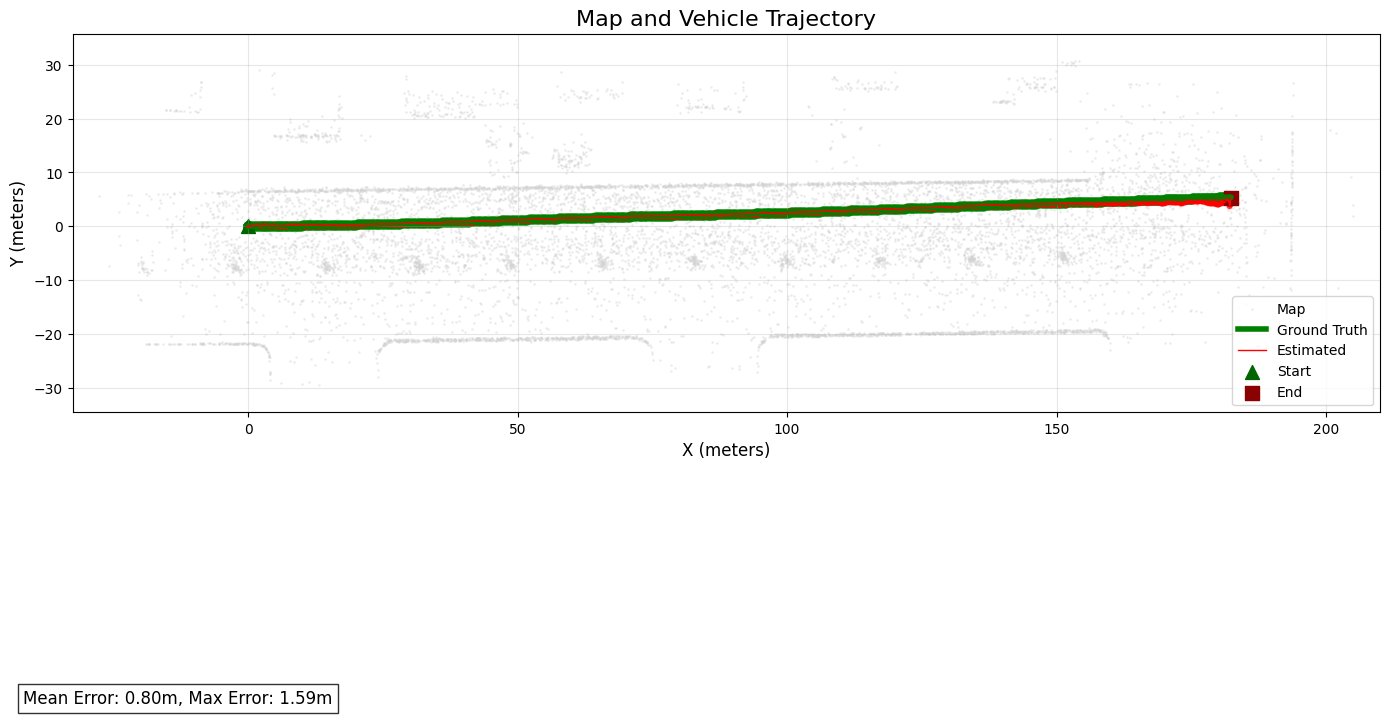

In [30]:
lateral_errors = calculate_lateral_errors(gt_positions, estimated_positions)
max_lateral_error = np.max(lateral_errors)
max_norm_error = np.max(np.linalg.norm(estimated_positions - gt_positions, axis=1))

# Plot results
plt.figure(figsize=(12, 8))

# Plot lateral and norm error over frames in the same plot
plt.plot(lateral_errors, label='Lateral Error')
plt.plot(np.linalg.norm(estimated_positions - gt_positions, axis=1), label='Norm Error', color='orange')
plt.axhline(y=1.2, color='r', linestyle='--', label='Max allowed error (1.2m)')

# Mark the position of the max lateral error
max_error_index = np.argmax(lateral_errors)
plt.scatter(max_error_index, max_lateral_error, color='red', s=100, label=f'Max Lateral Error: {max_lateral_error:.2f} m')
plt.text(max_error_index, max_lateral_error, f'{max_lateral_error:.2f} m', fontsize=9, ha='right')

# Mark the position of the max norm error
max_error_index = np.argmax(np.linalg.norm(estimated_positions - gt_positions, axis=1))
plt.scatter(max_error_index, max_norm_error, color='blue', s=100, label=f'Max Norm Error: {max_norm_error:.2f} m')
plt.text(max_error_index, max_norm_error, f'{max_norm_error:.2f} m', fontsize=9, ha='right')

plt.title("Lateral and Norm Error over Frames")
plt.xlabel("Frame")
plt.ylabel("Error (meters)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate cumulative errors
cumulative_lateral_errors = np.cumsum(lateral_errors)
cumulative_norm_errors = np.cumsum(np.linalg.norm(estimated_positions - gt_positions, axis=1))

# Plot cumulative lateral errors
plt.figure(figsize=(12, 8))
plt.plot(cumulative_lateral_errors, label='Cumulative Lateral Error')
plt.title("Cumulative Lateral Error over Frames")
plt.xlabel("Frame")
plt.ylabel("Cumulative Error (meters)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot cumulative norm errors
plt.figure(figsize=(12, 8))
plt.plot(cumulative_norm_errors, label='Cumulative Norm Error', color='orange')
plt.title("Cumulative Norm Error over Frames")
plt.xlabel("Frame")
plt.ylabel("Cumulative Error (meters)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot computation times across frames
plt.figure(figsize=(12, 8))
plt.plot(computation_times, label='Computation Time', color='purple')
plt.title("Computation Times over Frames")
plt.xlabel("Frame")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plot_map_and_trajectories(map_pcd, gt_positions, estimated_positions)